## Necessary code for loading Base model

### GPT Architecture

In [44]:
import torch
from torch import nn

In [45]:
class MultiHeadedAttention(nn.Module):
  def __init__(self, d_in, d_out, bias, dropout, num_heads, context_window):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out//num_heads
    self.w_q = nn.Linear(d_in, d_out, bias = bias)
    self.w_k = nn.Linear(d_in, d_out, bias = bias)
    self.w_v = nn.Linear(d_in, d_out, bias = bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask",
                         torch.triu(torch.ones(context_window, context_window),
                         diagonal = 1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)
    q = q.view(b, num_tokens, self.num_heads, self.head_dim)
    k = k.view(b, num_tokens, self.num_heads, self.head_dim)
    v = v.view(b, num_tokens, self.num_heads, self.head_dim)
    q = q.transpose(1, 2)
    k = k.transpose(1, 2)
    v = v.transpose(1, 2)
    #qkv = b, num_heads, num_tokens, head_dim
    product = q @ k.transpose(2,3)
    #(b, num_heads, num_tokens, head_dim) x (b, num_heads, head_dim, num_tokens)
    #=> product = (b, num_heads, num_tokens, num_tokens)
    mask = self.mask.bool()[:num_tokens, :num_tokens]
    product.masked_fill_(mask, -torch.inf)

    attn_score = torch.softmax(product / (k.shape[-1]**0.5)  , dim =  -1)
    attn_score = self.dropout(attn_score)

    context_vector = (attn_score @ v).transpose(1,2)
    #(b, num_heads, num_tokens, num_tokens) x (b, num_heads, num_tokens, head_dim)
    # => context vector = (b, num_heads, num_tokens, head_dim)
    # => context vector = (b, num_tokens, num_heads, head_dim)
    context_vector = context_vector.contiguous().view(b, num_tokens, self.d_out)
    context_vector = self.out_proj(context_vector)
    return context_vector

In [46]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
  #scale and shift are learnable params the model can change if it imporves performance

  def forward(self, x):
    mean = x.mean(dim = -1, keepdim = True)
    var = x.var(dim = -1, keepdim = True, unbiased = False)
    #unbiased = false => not using bessel correction of (n-1) instead of n
    z = (x - mean) / ((var+1e-5)**0.5)
    return self.scale*z + self.shift



class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))



class FeedForward(nn.Module):
  def __init__(self, x):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(x["emb_dim"], 4 * x["emb_dim"]),
        GELU(),
        nn.Linear(4 * x["emb_dim"], x["emb_dim"]))

  def forward(self, x):
    return self.layers(x)

In [47]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    #cfg is the configuration dictionary
    super().__init__()
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.attn = MultiHeadedAttention(d_in = cfg["emb_dim"], d_out = cfg["emb_dim"], bias = cfg["bias"],
                                           dropout = cfg["drop_rate"], num_heads = cfg["n_heads"],
                                           context_window = cfg["context_window"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.ff = FeedForward(cfg)

  def forward(self, x):
    residual = x
    x = self.norm1(x)
    x = self.attn(x)
    x = self.dropout(x)
    x = residual + x
    residual = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.dropout(x)
    return residual + x

In [48]:
class GeePeeTee(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embed = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.position_embed = nn.Embedding(cfg["context_window"], cfg["emb_dim"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.transformer = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.output = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = cfg["bias"])

  def forward(self, x):
    batch_size, seq_len = x.shape
    token_embed = self.token_embed(x)
    position_embed = self.position_embed(torch.arange(seq_len, device=x.device))
    y = token_embed + position_embed
    y = self.dropout(y)
    y = self.transformer(y)
    y = self.final_norm(y)
    logits = self.output(y)
    return logits

### Loading pretrained weights from openai

In [49]:
import urllib.request
url = (
 "https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch05/"
 "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [50]:
NEW_CONFIG = {
 "vocab_size": 50257, # Vocabulary size (BPE tokenizer)
 "context_window": 1024, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "bias": True #generally not used
}

In [51]:
gpt = GeePeeTee(NEW_CONFIG)
gpt.eval()

GeePeeTee(
  (token_embed): Embedding(50257, 768)
  (position_embed): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadedAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): Multi

In [52]:
def assign(left, right):
 if left.shape != right.shape:
  raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
 return torch.nn.Parameter(torch.tensor(right))


import numpy as np
def load_weights_into_gpt(gpt, params):
  gpt.position_embed.weight = assign(gpt.position_embed.weight, params['wpe'])
  gpt.token_embed.weight = assign(gpt.token_embed.weight, params['wte'])

  for b in range(len(params["blocks"])):

    Q_w, K_w, V_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
    gpt.transformer[b].attn.w_q.weight = assign(gpt.transformer[b].attn.w_q.weight, Q_w.T)
    gpt.transformer[b].attn.w_k.weight = assign(gpt.transformer[b].attn.w_k.weight, K_w.T)
    gpt.transformer[b].attn.w_v.weight = assign(gpt.transformer[b].attn.w_v.weight, V_w.T)

    Q_b, K_b, V_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
    gpt.transformer[b].attn.w_q.bias = assign(gpt.transformer[b].attn.w_q.bias, Q_b)
    gpt.transformer[b].attn.w_k.bias = assign(gpt.transformer[b].attn.w_k.bias, K_b)
    gpt.transformer[b].attn.w_v.bias = assign(gpt.transformer[b].attn.w_v.bias, V_b)

    gpt.transformer[b].attn.out_proj.weight = assign(gpt.transformer[b].attn.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.transformer[b].attn.out_proj.bias = assign(gpt.transformer[b].attn.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
    gpt.transformer[b].ff.layers[0].weight = assign(gpt.transformer[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.transformer[b].ff.layers[0].bias = assign(gpt.transformer[b].ff.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.transformer[b].ff.layers[2].weight = assign(gpt.transformer[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.transformer[b].ff.layers[2].bias = assign(gpt.transformer[b].ff.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

    gpt.transformer[b].norm1.scale = assign(gpt.transformer[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.transformer[b].norm1.shift = assign(gpt.transformer[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
    gpt.transformer[b].norm2.scale = assign(gpt.transformer[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.transformer[b].norm2.shift = assign(gpt.transformer[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

  gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
  gpt.output.weight = assign(gpt.output.weight, params["wte"])

In [53]:
def text2token(text, tokenizer):
  encoded = tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  return torch.tensor(encoded).unsqueeze(0)

def token2text(tokens, tokenizer):
  tokens = tokens.squeeze(0)
  return tokenizer.decode(tokens.tolist())


def generate(model, input, max_new_tokens, context_window,
             temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    cropped = input[:, -context_window:]  #only uses last len(context_window) tokens
    with torch.no_grad():
      logits = model(cropped)
    logits = logits[:, -1, :]
    #input/logits shape = (batch, tokens)
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      next = torch.multinomial(probs, num_samples=1)
    else:
      next = torch.argmax(logits, dim=-1, keepdim=True)

    if next == eos_id:
      break
    input = torch.cat((input, next), dim=1)
  return input

In [54]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
load_weights_into_gpt(gpt, params)
device = "cuda" if torch.cuda.is_available() else "cpu"
gpt.to(device)

token_ids = generate(model = gpt,
                     input = text2token("Greetings human, I am", tokenizer).to(device),
                     max_new_tokens = 40, context_window = NEW_CONFIG["context_window"],
                     temperature = 1.5, top_k = 50)
print("Output text:\n", token2text(token_ids, tokenizer))

Output text:
 Greetings human, I am Lenny the Hacking Guru :) I recently published my first short story collection and am now planning on continuing with a more "real" collection that focuses around my very own hacker art for which I use


# Preparing dataset

In [55]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data( url, zip_path, extracted_path, data_file_path):
  if data_file_path.exists():
    print(f"{data_file_path} already exists. Skipping download and extraction.")
    return

  with urllib.request.urlopen(url) as response:
    with open(zip_path, "wb") as out_file:
      out_file.write(response.read())

  with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extracted_path)

  original_file_path = Path(extracted_path) / "SMSSpamCollection"
  os.rename(original_file_path, data_file_path)
  print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [56]:
import pandas as pd
df = pd.read_csv(data_file_path, sep="\t", header = None, names=["Label", "Text"])
df.head()

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [57]:
df["Label"].value_counts()

,count
Label,
ham,4825
spam,747


In [58]:
def create_balanced_dataset(df):
  num_spam = len(df[df["Label"] == "spam"])
  subset_ham = df[df["Label"] == "ham"].sample(num_spam, random_state = 123)
  balanced_df = pd.concat([subset_ham, df[df["Label"]=="spam"]])
  return balanced_df

balanced_df = create_balanced_dataset(df)

In [59]:
balanced_df["Label"].value_counts()

,count
Label,
ham,747
spam,747


In [60]:
def df_split(df, train_ratio, valid_ratio):
  df = df.sample(frac = 1, random_state=123).reset_index(drop=True)
  length = len(df)
  train_end = int(length*train_ratio)
  valid_end = train_end + int(length*valid_ratio)

  train_df = df[:train_end]
  valid_df = df[train_end:valid_end]
  test_df = df[valid_end:]
  return train_df, valid_df, test_df

train_df, valid_df, test_df = df_split(balanced_df, 0.7, 0.1)
train_df.to_csv("train.csv", index=None)
valid_df.to_csv("valid.csv", index=None)
test_df.to_csv("test.csv", index=None)

Importing and creating tokenizer

In [61]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


Creating dataloader

In [62]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self, file, tokenizer, max_length=None, pad_token_id = 50256):
    self.data = pd.read_csv(file)
    self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]
    self.label_map = {"ham":0, "spam":1}

    #if none specified, default will be maximum in the training dataset
    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length
      self.encoded_texts = [encoded[:self.max_length] for encoded in self.encoded_texts] #truncates if longer than max length

    #naturally all will be smaller than default(MAX) , hence padded to max length
    self.encoded_texts = [encoded_text + [pad_token_id]*(self.max_length-len(encoded_text))
                            for encoded_text in self.encoded_texts]

  def __getitem__(self, index):
    encoded = self.encoded_texts[index]
    label_str = self.data.iloc[index]["Label"]
    label = self.label_map[label_str]
    return (torch.tensor(encoded, dtype=torch.long),torch.tensor(label, dtype=torch.long))

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max = 0
    for encoded in self.encoded_texts:
      length = len(encoded)
      if(length > max):
        max = length
    return max

In [63]:
train_dataset = SpamDataset(file="/content/train.csv", max_length=None, tokenizer=tokenizer)
valid_dataset = SpamDataset(file="/content/valid.csv", max_length=None, tokenizer=tokenizer)
test_dataset = SpamDataset(file="/content/test.csv", max_length=None, tokenizer=tokenizer)

In [64]:
train_dataset.max_length

120

In [65]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_dataloader = DataLoader(dataset = train_dataset, batch_size=batch_size,
                              shuffle = True, num_workers=num_workers, drop_last=True)

valid_dataloader = DataLoader(dataset = valid_dataset, batch_size=batch_size,
                              num_workers=num_workers, drop_last=False)

test_dataloader = DataLoader(dataset = test_dataset,batch_size=batch_size,
                             num_workers=num_workers, drop_last=False)

### Adding a classification head

In [66]:
for param in gpt.parameters():
  param.requires_grad = False

In [67]:
gpt

GeePeeTee(
  (token_embed): Embedding(50257, 768)
  (position_embed): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadedAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): Multi

In [68]:
num_classes = 2 #spam/ham
gpt.output = torch.nn.Linear(in_features= NEW_CONFIG["emb_dim"],
                             out_features= num_classes)
for param in gpt.transformer[-1].parameters():
  param.requires_grad = True
for param in gpt.final_norm.parameters():
  param.requires_grad = True

This last transformer block + last norm layer + output layer is trainable

In [69]:
gpt.to(device)
tokens = text2token("Hello, how are you", tokenizer)
tokens = tokens.to(device)
output = gpt(tokens)
print(output.shape)
#similiar to [batch, num_tokens, 50257]
print(output[:, -1, :])

torch.Size([1, 5, 2])
tensor([[-3.4163,  5.0371]], device='cuda:0', grad_fn=<SliceBackward0>)


In [70]:
label = torch.argmax(output[:, -1, :], dim = -1)
label.item()

1

In [71]:
def evaluate_accuracy(dataloader, model, device, num_batches = None):
  model.eval()
  correct, num_examples = 0, 0

  if num_batches is None:
    num_batches = len(dataloader)
  else:
    num_batches = min(len(dataloader), num_batches)

  for i, (input, target) in enumerate(dataloader):
    if i < num_batches:
      input = input.to(device)
      target = target.to(device)
      with torch.no_grad():
        output = model(input)[:, -1, :]
      predicted_label = torch.argmax(output, dim=-1)
      num_examples += predicted_label.shape[0]
      correct += ((predicted_label == target).sum().item())

    else:
      break
  return correct/num_examples

~0.5 accuracy makes sense since 1/2 chance of getting right

In [72]:
print(evaluate_accuracy(train_dataloader, gpt, device,num_batches=10 ))
print(evaluate_accuracy(valid_dataloader, gpt, device,num_batches=10 ))
print(evaluate_accuracy(test_dataloader, gpt, device,num_batches=10 ))

0.5375
0.45
0.4875


In [73]:
def loss_batch(input, target, model, device):
  input = input.to(device)
  target = target.to(device)
  output = model(input)[:, -1, :]
  loss = torch.nn.functional.cross_entropy(output, target)
  return loss

def loss_dataloader(dataloader, model, device, num_batches):
  total_loss = 0
  if len(dataloader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(dataloader)
  else:
    num_batches = min(len(dataloader), num_batches)

  for i, (input, target) in enumerate(dataloader):
    if i < num_batches:
      loss = loss_batch(input, target, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss/num_batches

In [74]:
with torch.no_grad():
  train_loss = loss_dataloader(train_dataloader, gpt, device, num_batches = 5)
  valid_loss = loss_dataloader(valid_dataloader, gpt, device, num_batches = 5)
  test_loss = loss_dataloader(test_dataloader, gpt, device, num_batches = 5)

print(f"train_loss: {train_loss} | valid_loss: {valid_loss} | test_loss: {test_loss} ")

train_loss: 2.318771633785218 | valid_loss: 2.524900960922241 | test_loss: 2.4126024723052977 


In [75]:
def trainModel(train_dataloader, valid_dataloader,optimizer,
               model, epochs,eval_freq, eval_iter, device):
  trainlosslist, validlosslist, trainacclist, validacclist = [], [], [], []
  examples_seen, global_step = 0, -1

  for epoch in range(epochs):
    model.train()
    for input, target in train_dataloader:
      optimizer.zero_grad()
      loss = loss_batch(input, target, model, device)
      loss.backward()
      optimizer.step()
      examples_seen += input.shape[0]
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, valid_loss = evaluate_model(model, train_dataloader, valid_dataloader, device, eval_iter)
        trainlosslist.append(train_loss)
        validlosslist.append(valid_loss)
        print(f"Epoch: {epoch+1} (Step {global_step:06d}) | Train loss {train_loss:.3f} | Valid loss {valid_loss:.3f}")

      train_acc = evaluate_accuracy(train_dataloader, model, device, num_batches = eval_iter)
      valid_acc = evaluate_accuracy(valid_dataloader, model, device, num_batches = eval_iter)
      trainacclist.append(train_acc)
      validacclist.append(valid_acc)
      print(f"Train acc: {train_acc} | Valid acc: {valid_acc}")

  return trainlosslist, validlosslist, trainacclist, validacclist, examples_seen


In [76]:
def evaluate_model(model, train_dataloader, valid_dataloader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = loss_dataloader(train_dataloader, model, device, num_batches=eval_iter)
    valid_loss = loss_dataloader(valid_dataloader, model, device, num_batches=eval_iter)
  model.train()
  return train_loss, valid_loss

In [77]:
device = "cuda" if torch.cuda.is_available() else "cpu"
optimizer = torch.optim.AdamW(gpt.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
trainlosslist, validlosslist, trainacclist, validacclist, examples_seen = trainModel(train_dataloader, valid_dataloader,
                                                                                     optimizer, gpt, num_epochs, 50, 5, device)


Epoch: 1 (Step 000000) | Train loss 2.045 | Valid loss 2.358
Train acc: 0.4 | Valid acc: 0.5
Train acc: 0.4 | Valid acc: 0.5
Train acc: 0.425 | Valid acc: 0.5
Train acc: 0.475 | Valid acc: 0.5
Train acc: 0.525 | Valid acc: 0.5
Train acc: 0.4 | Valid acc: 0.5
Train acc: 0.475 | Valid acc: 0.5
Train acc: 0.55 | Valid acc: 0.5
Train acc: 0.425 | Valid acc: 0.5
Train acc: 0.525 | Valid acc: 0.5
Train acc: 0.575 | Valid acc: 0.5
Train acc: 0.45 | Valid acc: 0.5
Train acc: 0.55 | Valid acc: 0.5
Train acc: 0.275 | Valid acc: 0.575
Train acc: 0.4 | Valid acc: 0.65
Train acc: 0.5 | Valid acc: 0.675
Train acc: 0.45 | Valid acc: 0.725
Train acc: 0.425 | Valid acc: 0.8
Train acc: 0.6 | Valid acc: 0.725
Train acc: 0.475 | Valid acc: 0.725
Train acc: 0.5 | Valid acc: 0.675
Train acc: 0.65 | Valid acc: 0.65
Train acc: 0.45 | Valid acc: 0.65
Train acc: 0.55 | Valid acc: 0.625
Train acc: 0.475 | Valid acc: 0.6
Train acc: 0.6 | Valid acc: 0.575
Train acc: 0.575 | Valid acc: 0.575
Train acc: 0.675 | Vali

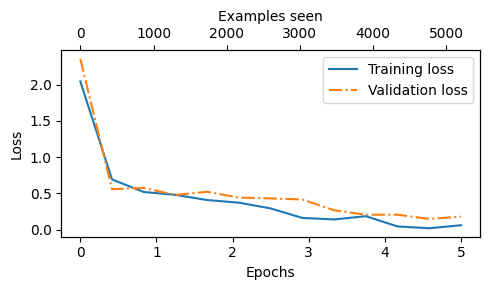

In [78]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen,
                train_values, val_values, label="loss"):
  fig, ax1 = plt.subplots(figsize=(5, 3))
  ax1.plot(epochs_seen, train_values, label=f"Training {label}")
  ax1.plot(epochs_seen, val_values, linestyle="-.",label=f"Validation {label}")
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel(label.capitalize())
  ax1.legend()

  ax2 = ax1.twiny()
  ax2.plot(examples_seen, train_values, alpha=0)
  ax2.set_xlabel("Examples seen")
  fig.tight_layout()
  plt.savefig(f"{label}-plot.pdf")
  plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(trainlosslist))
examples_seen_tensor = torch.linspace(0, examples_seen, len(trainlosslist))
plot_values(epochs_tensor, examples_seen_tensor, trainlosslist, validlosslist)

In [80]:
train_accuracy = evaluate_accuracy(train_dataloader, gpt, device)
val_accuracy = evaluate_accuracy(valid_dataloader, gpt, device)
test_accuracy = evaluate_accuracy(test_dataloader, gpt, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.69%
Validation accuracy: 95.30%
Test accuracy: 96.00%


Model fits extremely well

In [81]:
def checkSpam(text, model, tokenizer, device, train_max_length, pad_token_id=50256):
  model.eval()
  input_ids = tokenizer.encode(text)

 #truncate if longer than training length since model has learnt on this parameter
  if len(input_ids) > train_max_length:
    input_ids = input_ids[:train_max_length]
  #Pad to training max length if less
  input_ids += [pad_token_id] * (train_max_length - len(input_ids))

  input_tensor = torch.tensor( input_ids, device=device).unsqueeze(0)

  with torch.no_grad():
    logits = model(input_tensor)[:, -1, :]
  predicted_label = torch.argmax(logits, dim=-1).item()
  return "spam" if predicted_label == 1 else "not spam"

In [82]:
checkSpam("Does the classifier work?", gpt, tokenizer, device, train_dataset.max_length)

'not spam'